In [1]:
%%time
import xarray as xr
from xarray.testing import assert_equal

import matplotlib.pylab as plt
import cartopy.crs as ccrs

import numpy as np
import re
import os 
from one_pass.opa import Opa # using v0.3.5

from aqua import Reader, catalogue
# catalogue(configdir='/home/a/a270223/AQUA/config')
catalogue(configdir='/work/ab0995/a270223/AQUA/config')
# path = '/home/a/a270223/AQUA/config/levante/catalog.yaml'
path = '/work/ab0995/a270223/AQUA/config/levante/catalog.yaml'

def save_subplots_as_jpeg(output_directory, filename, fig):
    """
    Saves the subplots as a JPEG image file.

    Parameters:
        config (dict): The configuration dictionary containing the output directory.
        filename (str): The name of the output file.
        fig (plt.Figure): The figure object containing the subplots.
    """

    # Set the output file path
    output_file = os.path.join(output_directory, filename)

    # Save the figure as a JPEG file. fig.savefig() or plt.savefig() should accomplish the same task of saving the figure to a file. (DPI = dots per inch)
    fig.savefig(output_file, dpi=500, format='jpeg')

IFS	tco3999-ng5	2.8km experiment, coupled with FESOM
	- ICMGG_atm2d	original 2d output
	- ICMU_atm2d	original 2d output (lnsp)
	- ICMU_atm3d	original 3d output
	- interpolated_global	NN interpolation to 5400x2700 grid (lon=[-180,180], lat=[-90, 90])
	- lra-r100-monthly	LRA data monthly at r100
IFS	tco2559-ng5	4km experiment, coupled with FESOM
	- ICMGG_atm2d	original 2d output
	- ICMU_atm2d	original 2d output (lnsp)
	- ICMU_atm3d	original 3d output
	- interpolated_global	NN interpolation to 5400x2700 grid (lon=[-180,180], lat=[-90, 90])
	- lra-r100-monthly	LRA data monthly at r100
IFS	tco1279-orca025	9km baseline, coupled to NEMO, deep conv ON
	- ICMGG_atm2d	original 2d output
	- ICMU_atm2d	original 2d output (lnsp)
	- ICMU_atm3d	original 3d output
	- lra-r100-monthly	LRA data monthly at r100
IFS	tco2559-ng5-cycle3	main 4.4km Cycle 3 experiment, coupled with FESOM 5km
	- 2D_1h_native	
	- 3D_1h_native	
	- 2D_monthly_0.25deg	
	- 3D_monthly_0.25deg	
	- 2D_monthly_1deg	
	- 3D_monthly_1deg	

# Initializing AQUA reader for FESOM cycle 3 data.

In [2]:
reader = Reader(model='FESOM', exp='tco2559-ng5-cycle3', source="2D_daily_native", regrid="r025")

## Running OPA with streaming data to compute monthly std for FESOM 
(start date 2024-06-01 just doing 6 months data for testing)

In [48]:
%%time

opa_dict = {"stat_freq": "monthly",
"output_freq": "monthly",
"stat": "std",
"time_step": 1440,
"variable": "zos",
"save": True,
"checkpoint": True,
"checkpoint_filepath": "tests_fesom_mon/",
"out_filepath": "tests_fesom_mon"}

reader.reset_stream()
data_gen = reader.retrieve(streaming_generator=True, stream_step=15, stream_unit = 'days', stream_startdate='2024-06-01')

for data in data_gen:
    print(f"start_date: {data.time[0].values} stop_date: {data.time[-1].values}")
    zos = data['zos']
    monthly_std = Opa(opa_dict)
    std = monthly_std.compute(zos)

start_date: 2024-06-01T23:56:00.000000000 stop_date: 2024-06-15T23:56:00.000000000
4.3772 s to load dask
start_date: 2024-06-16T23:56:00.000000000 stop_date: 2024-06-30T23:56:00.000000000
finished saving in 7.3388 s
start_date: 2024-07-01T23:56:00.000000000 stop_date: 2024-07-15T23:56:00.000000000
4.4643 s to load dask
start_date: 2024-07-16T23:56:00.000000000 stop_date: 2024-07-30T23:56:00.000000000
7.1045 s to load dask
start_date: 2024-07-31T23:56:00.000000000 stop_date: 2024-08-14T23:56:00.000000000
finished saving in 7.3252 s
4.3564 s to load dask
start_date: 2024-08-15T23:56:00.000000000 stop_date: 2024-08-29T23:56:00.000000000
6.7076 s to load dask
start_date: 2024-08-30T23:56:00.000000000 stop_date: 2024-09-13T23:56:00.000000000
finished saving in 7.4807 s
4.1206 s to load dask
start_date: 2024-09-14T23:56:00.000000000 stop_date: 2024-09-28T23:56:00.000000000
6.5968 s to load dask
start_date: 2024-09-29T23:56:00.000000000 stop_date: 2024-10-13T23:56:00.000000000
finished saving

### Visualizing the results that got saved in the tests_fesom_mon folder

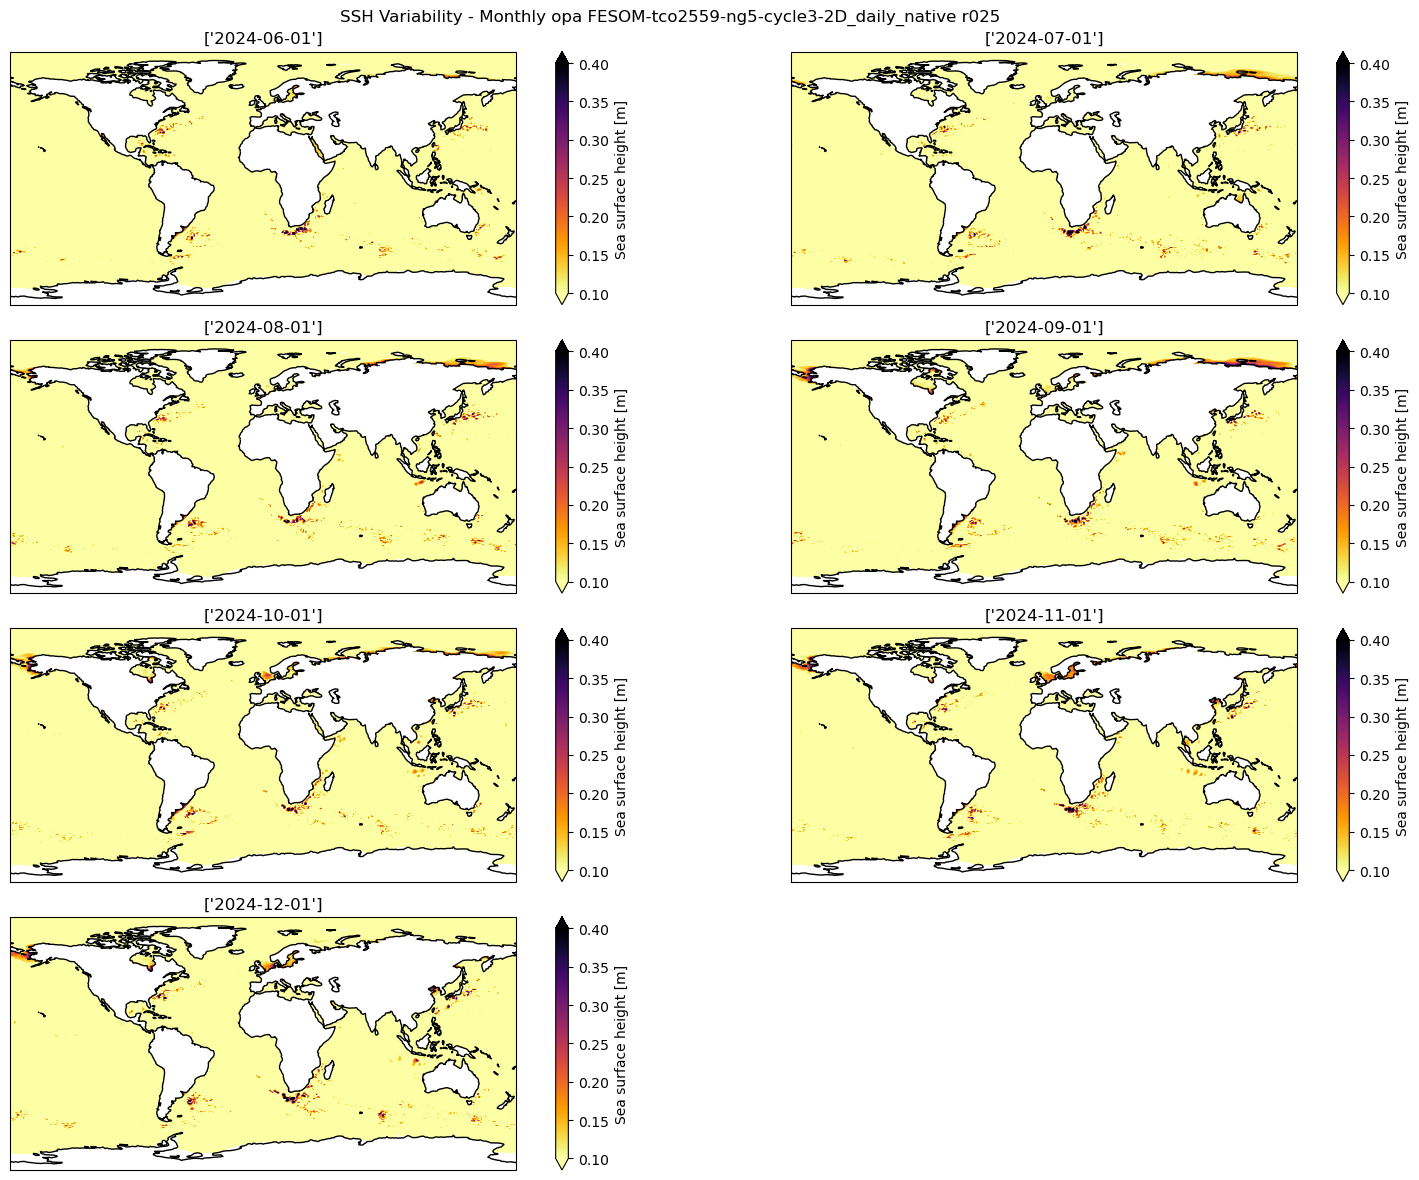

In [49]:
folder_path = 'tests_fesom_mon'
data_list = []
# Get a list of filenames in the folder
file_names = os.listdir(folder_path)

# Sort the filenames based on the timestamps they represent (e.g., 2024_06, 2024_07)
sorted_file_names = sorted(file_names, key=lambda x: tuple(map(int, re.findall(r'\d+', x))))

for filename in sorted_file_names:
    file_path = os.path.join(folder_path, filename)
    # Check if the file is in NetCDF format
    if file_path.endswith('.nc'):
        data = xr.open_dataset(file_path)
        data_list.append(data)

# reader = Reader(model='FESOM', exp='tco2559-ng5-cycle3', source="2D_daily_native", regrid="r025")
regridded_data_list = []
for data in data_list:
    data = reader.regrid(data)
    regridded_data_list.append(data)

nrows = len(regridded_data_list)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle("SSH Variability - Monthly opa FESOM-tco2559-ng5-cycle3-2D_daily_native r025")
axes = np.ravel(axes)
for i, data in enumerate(regridded_data_list):
    ax = axes[i]
    data['zos'].plot(ax=ax, transform=ccrs.PlateCarree(), vmin=0.1, vmax=0.4, cmap=plt.cm.inferno.reversed())
    ax.coastlines()
    ax.set_title(data['time'].dt.strftime('%Y-%m-%d').values)

if len(regridded_data_list) < len(axes):
    for j in range(len(regridded_data_list), len(axes)):
        fig.delaxes(axes[j])

# fig.subplots_adjust(wspace=0.4, hspace=0.8)
fig.tight_layout()
plt.show()

save_subplots_as_jpeg(os.getcwd(), "ssh_fesom_monthly.jpeg", fig)

## Running OPA with streaming data to compute continuous std for FESOM 
(start date 2024-06-01 - again 6 months but this time the last month data should contain cumulative std over the whole time duration)

In [47]:
%%time
opa_dict = {"stat_freq": "continuous",
"output_freq": "monthly",
"stat": "std",
"time_step": 1440,
"variable": "zos",
"save": True,
"checkpoint": True,
"checkpoint_filepath": "tests_fesom_cont/",
"out_filepath": "tests_fesom_cont"}

# reader = Reader(model='FESOM', exp='tco2559-ng5-cycle3', source="2D_daily_native", regrid="r025")

reader.reset_stream()
data_gen = reader.retrieve(streaming_generator=True, stream_step=15, stream_unit = 'days', stream_startdate='2024-06-01')

for data in data_gen:
    print(f"start_date: {data.time[0].values} stop_date: {data.time[-1].values}")
    zos = data['zos']
    monthly_std = Opa(opa_dict)
    std = monthly_std.compute(zos)

start_date: 2024-06-01T23:56:00.000000000 stop_date: 2024-06-15T23:56:00.000000000
initialising continuous statistic
6.4406 s to load dask
start_date: 2024-06-16T23:56:00.000000000 stop_date: 2024-06-30T23:56:00.000000000
9.1035 s to load dask
finished saving in 0.1814 s
start_date: 2024-07-01T23:56:00.000000000 stop_date: 2024-07-15T23:56:00.000000000
11.2387 s to load dask
start_date: 2024-07-16T23:56:00.000000000 stop_date: 2024-07-30T23:56:00.000000000
13.1247 s to load dask
start_date: 2024-07-31T23:56:00.000000000 stop_date: 2024-08-14T23:56:00.000000000
finished saving in 12.8207 s
16.7216 s to load dask
start_date: 2024-08-15T23:56:00.000000000 stop_date: 2024-08-29T23:56:00.000000000
19.3039 s to load dask
start_date: 2024-08-30T23:56:00.000000000 stop_date: 2024-09-13T23:56:00.000000000
finished saving in 17.5494 s
21.5535 s to load dask
start_date: 2024-09-14T23:56:00.000000000 stop_date: 2024-09-28T23:56:00.000000000
23.1968 s to load dask
start_date: 2024-09-29T23:56:00.00

### Visualizing the results that got saved in the tests_fesom_cont folder

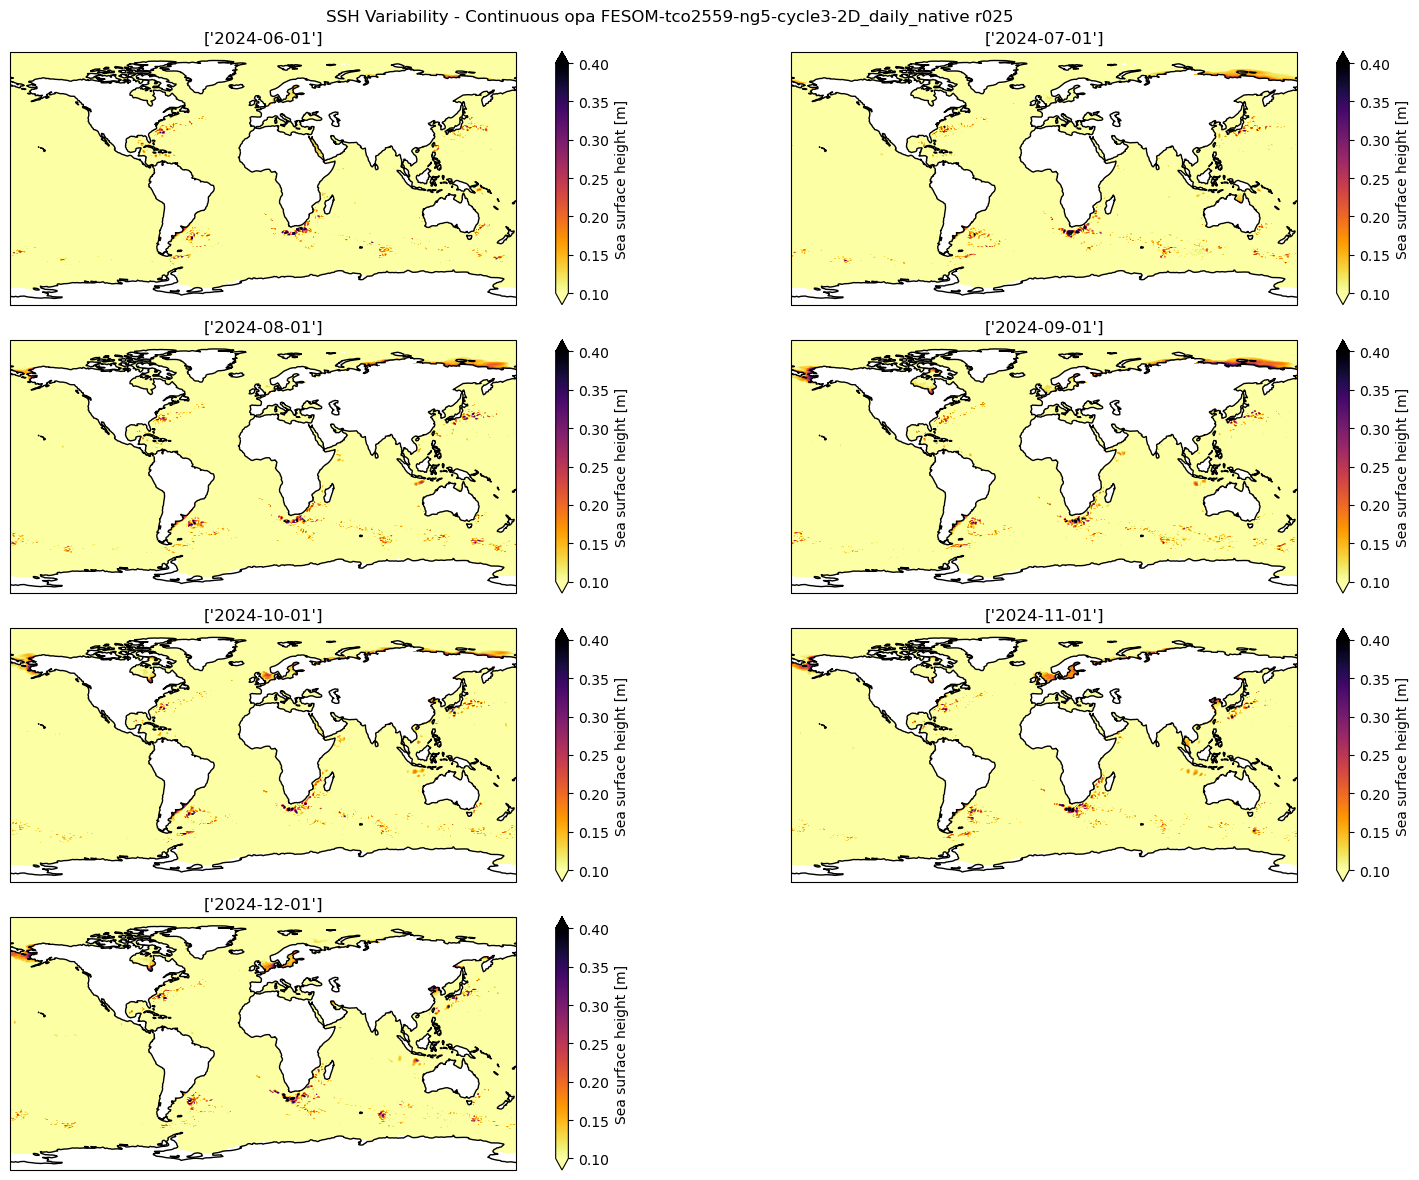

In [50]:
folder_path = 'tests_fesom_cont'
data_list = []
# Get a list of filenames in the folder
file_names = os.listdir(folder_path)

# Sort the filenames based on the timestamps they represent (e.g., 2024_06, 2024_07)
sorted_file_names = sorted(file_names, key=lambda x: tuple(map(int, re.findall(r'\d+', x))))

for filename in sorted_file_names:
    file_path = os.path.join(folder_path, filename)
    # Check if the file is in NetCDF format
    if file_path.endswith('.nc'):
        data = xr.open_dataset(file_path)
        data_list.append(data)

# reader = Reader(model='FESOM', exp='tco2559-ng5-cycle3', source="2D_daily_native", regrid="r025")
regridded_data_list = []
for data in data_list:
    data = reader.regrid(data)
    regridded_data_list.append(data)

nrows = len(regridded_data_list)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle("SSH Variability - Continuous opa FESOM-tco2559-ng5-cycle3-2D_daily_native r025")
axes = np.ravel(axes)
for i, data in enumerate(regridded_data_list):
    ax = axes[i]
    data['zos'].plot(ax=ax, transform=ccrs.PlateCarree(), vmin=0.1, vmax=0.4, cmap=plt.cm.inferno.reversed())
    ax.coastlines()
    ax.set_title(data['time'].dt.strftime('%Y-%m-%d').values)

if len(regridded_data_list) < len(axes):
    for j in range(len(regridded_data_list), len(axes)):
        fig.delaxes(axes[j])

# fig.subplots_adjust(wspace=0.4, hspace=0.8)
fig.tight_layout()
plt.show()

save_subplots_as_jpeg(os.getcwd(), "ssh_fesom_cont.jpeg", fig)

### Plots for monthly std and cumulative std (continuous) look very similar.
### Comparing the data in individual files to see if it is different. First month should be the same, rest different.

In [94]:
monthly_folder = 'tests_fesom_mon'
continuous_folder = 'tests_fesom_cont'

file_names = os.listdir(monthly_folder)

# Sort the filenames based on the timestamps they represent (e.g., 2024_06, 2024_07)
sorted_file_names = sorted(file_names, key=lambda x: tuple(map(int, re.findall(r'\d+', x))))

# Iterate over the files in the monthly folder
for file_name in sorted_file_names:
    if file_name.endswith('.nc'):
        monthly_file = os.path.join(monthly_folder, file_name)
        year, month = file_name.split('_')[0:2]  # Extract the year and month from the file name
        
        # Check if a corresponding file exists in the continuous folder
        continuous_file = os.path.join(continuous_folder, f'{year}_{month}_zos_continuous_std.nc')
        if os.path.exists(continuous_file):
            # Open the monthly and continuous files as xarray datasets
            monthly_data = xr.open_dataset(monthly_file)
            continuous_data = xr.open_dataset(continuous_file)
            
#             # Get the first and last timestamps of each file.
#             monthly_first_timestamp = monthly_data['time'].values[0]
#             monthly_last_timestamp = monthly_data['time'].values[-1]
#             continuous_first_timestamp = continuous_data['time'].values[0]
#             continuous_last_timestamp = continuous_data['time'].values[-1]

#             print(f"Comparing {file_name} and {os.path.basename(continuous_file)}:")
#             print(f"Monthly Data - First Timestamp: {monthly_first_timestamp}, Last Timestamp: {monthly_last_timestamp}")
#             print(f"Continuous Data - First Timestamp: {continuous_first_timestamp}, Last Timestamp: {continuous_last_timestamp}")
            
            try:
                # Compare the datasets
                assert_equal(monthly_data, continuous_data)
                print(f"The data in {file_name} and {os.path.basename(continuous_file)} is the same.")
            except AssertionError:
                print(f"The data in {file_name} and {os.path.basename(continuous_file)} is different.")
            finally:
                # Close the datasets
                monthly_data.close()
                continuous_data.close()
        else:
            print(f"No corresponding file found for {file_name} in the continuous folder.")


The data in 2024_06_zos_monthly_std.nc and 2024_06_zos_continuous_std.nc is the same.
The data in 2024_07_zos_monthly_std.nc and 2024_07_zos_continuous_std.nc is different.
The data in 2024_08_zos_monthly_std.nc and 2024_08_zos_continuous_std.nc is different.
The data in 2024_09_zos_monthly_std.nc and 2024_09_zos_continuous_std.nc is different.
The data in 2024_10_zos_monthly_std.nc and 2024_10_zos_continuous_std.nc is different.
The data in 2024_11_zos_monthly_std.nc and 2024_11_zos_continuous_std.nc is different.
The data in 2024_12_zos_monthly_std.nc and 2024_12_zos_continuous_std.nc is different.


In the hindsight it doesnt make sense to print the first and last timestamp on the OPA data because it compresses it over the timespan from streaming timesteps.

# Running FESOM std on disk data to check if the cumulative std from OPA matches the computation performed on disc data.
Disc data std computation for the same 6 month time duration should match the OPA results.

In [16]:
fesom_no_stream = reader.retrieve(fix=True)
fesom_no_stream = fesom_no_stream['zos']

In [ ]:
import dask
from distributed import Client, LocalCluster
dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})
cluster = LocalCluster(n_workers=16, threads_per_worker=1)
client = Client(cluster)

client

In [18]:
fesom_cat_std = fesom_no_stream.sel(time=slice("2024-06-01", "2024-12-31")).std(axis=0).persist()
fesom_cat_std

<xarray.DataArray 'zos' (nod2: 7402886)>
dask.array<_sqrt, shape=(7402886,), dtype=float32, chunksize=(7402886,), chunktype=numpy.ndarray>
Dimensions without coordinates: nod2
Attributes:
    description:  sea surface elevation
    long_name:    Sea surface height
    units:        m
    history:      2023-07-20 09:32:44 variable derived by AQUA fixer;\n
    paramId:      262124
    cfVarName:    zos
    shortName:    zos
    derived:      ssh

In [21]:
output_file = os.path.join(os.getcwd(), "fesom_disc.nc")
fesom_cat_std.to_netcdf(output_file)

In [46]:
client.close()
cluster.close()

## These datasets should be equal but for some reason, they are not?!

In [52]:
file_path = 'fesom_disc.nc'
fesom_disc = xr.open_dataset(file_path)
file_path = 'tests_fesom_cont/2024_12_zos_continuous_std.nc'
fesom_opa = xr.open_dataset(file_path)

if fesom_disc.identical(fesom_opa):
    print("The datasets are identical.")
else:
    print("The datasets are not identical.")

The datasets are not identical.


### Calculating the difference between the two datasets and plotting.

In [84]:
# # Align the datasets along the 'nod2' dimension
# fesom_disc_aligned, fesom_opa_aligned = xr.align(fesom_disc, fesom_opa, join='exact')
# difference = fesom_disc_aligned - fesom_opa_aligned
# difference = fesom_disc['zos'] - fesom_opa['zos']
# difference

# Broadcast 'fesom_opa' along the 'time' dimension to match the shape of 'fesom_disc'
fesom_disc_broadcasted = fesom_disc.broadcast_like(fesom_opa)

# Perform the difference
difference = fesom_disc_broadcasted['zos'] - fesom_opa['zos']
difference

<xarray.DataArray 'zos' (time: 1, nod2: 7402886)>
array([[0.0113771 , 0.01294243, 0.01426435, ..., 0.01299801, 0.01139685,
        0.01392239]])
Coordinates:
  * time     (time) datetime64[ns] 2024-12-01T23:56:00
Dimensions without coordinates: nod2
Attributes:
    description:  sea surface elevation
    long_name:    Sea surface height
    units:        m
    history:      2023-07-20 09:32:44 variable derived by AQUA fixer;\n
    paramId:      262124
    cfVarName:    zos
    shortName:    zos
    derived:      ssh

In [85]:
regridded_diff = reader.regrid(difference)
regridded_diff

<xarray.DataArray 'zos' (time: 1, lat: 720, lon: 1440)>
dask.array<reshape, shape=(1, 720, 1440), dtype=float64, chunksize=(1, 720, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2024-12-01T23:56:00
  * lat      (lat) float64 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
Attributes:
    description:  sea surface elevation
    long_name:    Sea surface height
    units:        m
    history:      2023-07-20 09:32:44 variable derived by AQUA fixer;\n2023-0...
    paramId:      262124
    cfVarName:    zos
    shortName:    zos
    derived:      ssh
    regridded:    1

In [74]:
regridded_fesom_disc = reader.regrid(fesom_disc)
regridded_fesom_opa = reader.regrid(fesom_opa)

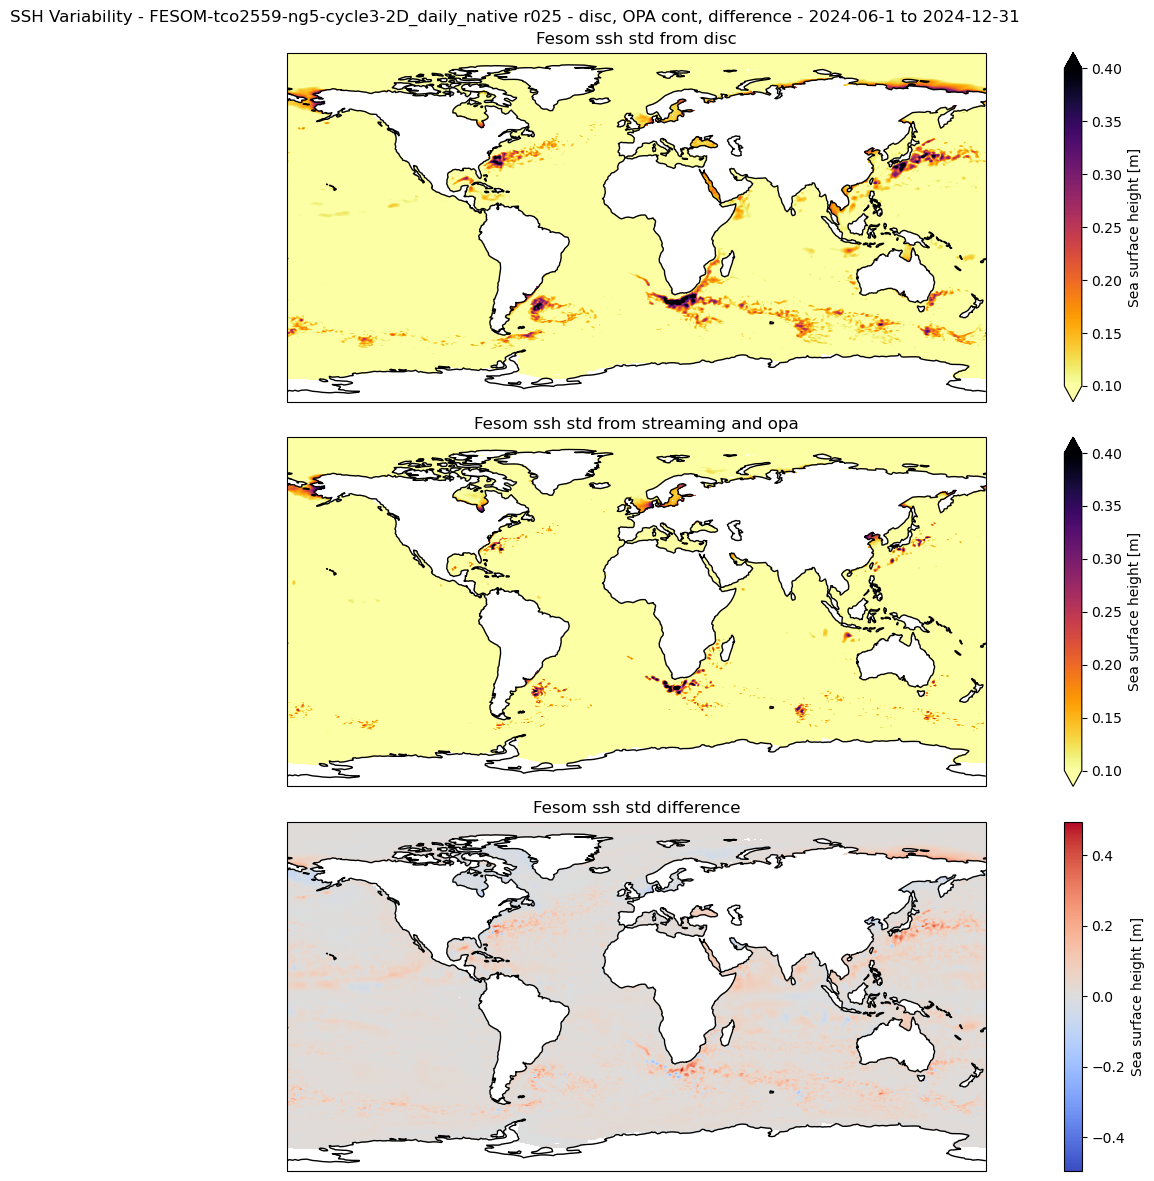

In [91]:
fig, axes = plt.subplots(nrows=3, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle("SSH Variability - FESOM-tco2559-ng5-cycle3-2D_daily_native r025 - disc, OPA cont, difference - 2024-06-1 to 2024-12-31")

# Plot the first dataset on the first subplot
regridded_fesom_disc['zos'].plot(ax=axes[0], transform=ccrs.PlateCarree(), vmin=0.1, vmax=0.4, cmap=plt.cm.inferno.reversed())
axes[0].set_title("Fesom ssh std from disc")
axes[0].coastlines()

# Plot the second dataset on the second subplot
regridded_fesom_opa['zos'].plot(ax=axes[1], transform=ccrs.PlateCarree(), vmin=0.1, vmax=0.4, cmap=plt.cm.inferno.reversed())
axes[1].set_title("Fesom ssh std from streaming and opa")
axes[1].coastlines()

# Plot the third dataset on the third subplot
regridded_diff.plot(ax=axes[2], transform=ccrs.PlateCarree(), cmap='coolwarm')
axes[2].set_title("Fesom ssh std difference")
axes[2].coastlines()

fig.tight_layout()
plt.show()

save_subplots_as_jpeg(os.getcwd(), "ssh_disc_opa_diff.jpeg", fig)

### a) opa at monthly frequency, b) opa at continuous frequency but run for the month c) disc data std
OPA accuracy tests for variance and std across monthly time scales confirm that they are the same when compared with numpy. Checking if it's a problem with the 'continuous' implementation or with the opa calculation it's self

### a) opa at monthly frequency for one month 

In [3]:
%%time

opa_dict = {"stat_freq": "monthly",
"output_freq": "monthly",
"stat": "std",
"time_step": 1440,
"variable": "zos",
"save": True,
"checkpoint": True,
"checkpoint_filepath": "tests_fesom_mon/",
"out_filepath": "tests_fesom_mon"}

reader.reset_stream()
data_gen = reader.retrieve(streaming_generator=True, stream_step=15, stream_unit = 'days', stream_startdate='2024-12-01')

for data in data_gen:
    print(f"start_date: {data.time[0].values} stop_date: {data.time[-1].values}")
    zos = data['zos']
    monthly_std = Opa(opa_dict)
    std = monthly_std.compute(zos)

start_date: 2024-12-01T23:56:00.000000000 stop_date: 2024-12-15T23:56:00.000000000
6.5436 s to load dask
start_date: 2024-12-16T23:56:00.000000000 stop_date: 2024-12-30T23:56:00.000000000
7.6989 s to load dask
start_date: 2024-12-31T23:56:00.000000000 stop_date: 2024-12-31T23:56:00.000000000
finished saving in 7.2678 s
CPU times: user 27.9 s, sys: 1min 40s, total: 2min 8s
Wall time: 1min 40s


### b) opa at continuous frequency for one month

In [4]:
%%time
opa_dict = {"stat_freq": "continuous",
"output_freq": "monthly",
"stat": "std",
"time_step": 1440,
"variable": "zos",
"save": True,
"checkpoint": True,
"checkpoint_filepath": "tests_fesom_cont/",
"out_filepath": "tests_fesom_cont"}

reader.reset_stream()
data_gen = reader.retrieve(streaming_generator=True, stream_step=15, stream_unit = 'days', stream_startdate='2024-12-01')

for data in data_gen:
    print(f"start_date: {data.time[0].values} stop_date: {data.time[-1].values}")
    zos = data['zos']
    monthly_std = Opa(opa_dict)
    std = monthly_std.compute(zos)

start_date: 2024-12-01T23:56:00.000000000 stop_date: 2024-12-15T23:56:00.000000000
initialising continuous statistic
4.2117 s to load dask
start_date: 2024-12-16T23:56:00.000000000 stop_date: 2024-12-30T23:56:00.000000000
6.6324 s to load dask
start_date: 2024-12-31T23:56:00.000000000 stop_date: 2024-12-31T23:56:00.000000000
7.0243 s to load dask
finished saving in 0.0438 s
CPU times: user 25.9 s, sys: 2min 26s, total: 2min 52s
Wall time: 31.4 s


In [5]:
%%time
fesom_no_stream = reader.retrieve(fix=True)
fesom_no_stream = fesom_no_stream['zos']
fesom_cat_std = fesom_no_stream.sel(time=slice("2024-12-01", "2024-12-31")).std(axis=0)
output_file = os.path.join(os.getcwd(), "fesom_disc.nc")
fesom_cat_std.to_netcdf(output_file)

CPU times: user 10.7 s, sys: 29.6 s, total: 40.3 s
Wall time: 14 s


In [11]:
# Seems like this is a quick way to check if two datasets are exactly the same in terms of structure and values. But assert_equal is better to compare data.
file_path = 'tests_fesom_mon/2024_12_zos_monthly_std.nc'
fesom_month_opa = xr.open_dataset(file_path)
file_path = 'tests_fesom_cont/2024_12_zos_continuous_std.nc'
fesom_opa = xr.open_dataset(file_path)

if fesom_month_opa.identical(fesom_opa):
    print("The datasets are identical.")
else:
    print("The datasets are not identical.")

The datasets are not identical.


In [17]:
fesom_month_opa['zos'].isel(time=slice(0, 10)).load()

<xarray.DataArray 'zos' (time: 1, nod2: 7402886)>
array([[0.03037915, 0.02753933, 0.02567192, ..., 0.02756085, 0.02818515,
        0.02732916]])
Coordinates:
  * time     (time) datetime64[ns] 2024-12-01T23:56:00
Dimensions without coordinates: nod2
Attributes:
    description:  sea surface elevation
    long_name:    Sea surface height
    units:        m
    history:      2023-07-21 10:38:46 variable derived by AQUA fixer;\n
    paramId:      262124
    cfVarName:    zos
    shortName:    zos
    derived:      ssh
    OPA:          monthly std calculated using one-pass algorithm

In [16]:
fesom_opa['zos'].isel(time=slice(0, 10)).load()

<xarray.DataArray 'zos' (time: 1, nod2: 7402886)>
array([[0.03037915, 0.02753933, 0.02567192, ..., 0.02756085, 0.02818515,
        0.02732916]])
Coordinates:
  * time     (time) datetime64[ns] 2024-12-01T23:56:00
Dimensions without coordinates: nod2
Attributes:
    description:  sea surface elevation
    long_name:    Sea surface height
    units:        m
    history:      2023-07-21 10:41:47 variable derived by AQUA fixer;\n
    paramId:      262124
    cfVarName:    zos
    shortName:    zos
    derived:      ssh
    OPA:          continuous std calculated using one-pass algorithm

In [12]:
monthly_folder = 'tests_fesom_mon'
continuous_folder = 'tests_fesom_cont'

file_names = os.listdir(monthly_folder)

# Sort the filenames based on the timestamps they represent (e.g., 2024_06, 2024_07)
sorted_file_names = sorted(file_names, key=lambda x: tuple(map(int, re.findall(r'\d+', x))))

# Iterate over the files in the monthly folder
for file_name in sorted_file_names:
    if file_name.endswith('.nc'):
        monthly_file = os.path.join(monthly_folder, file_name)
        year, month = file_name.split('_')[0:2]  # Extract the year and month from the file name
        
        # Check if a corresponding file exists in the continuous folder
        continuous_file = os.path.join(continuous_folder, f'{year}_{month}_zos_continuous_std.nc')
        if os.path.exists(continuous_file):
            # Open the monthly and continuous files as xarray datasets
            monthly_data = xr.open_dataset(monthly_file)
            continuous_data = xr.open_dataset(continuous_file)
            
            try:
                # Compare the datasets
                assert_equal(monthly_data, continuous_data)
                print(f"The data in {file_name} and {os.path.basename(continuous_file)} is the same.")
            except AssertionError:
                print(f"The data in {file_name} and {os.path.basename(continuous_file)} is different.")
            finally:
                # Close the datasets
                monthly_data.close()
                continuous_data.close()
        else:
            print(f"No corresponding file found for {file_name} in the continuous folder.")


The data in 2024_12_zos_monthly_std.nc and 2024_12_zos_continuous_std.nc is the same.


### Comparing disc data with monthly opa data

In [22]:
file_path = 'fesom_disc.nc'
fesom_disc = xr.open_dataset(file_path)
file_path = 'tests_fesom_mon/2024_12_zos_monthly_std.nc'
fesom_month_opa = xr.open_dataset(file_path)

try:
    assert_equal(fesom_disc, fesom_month_opa)
    print('values are equal')
except AssertionError:
    print('values are different')

values are different


### Comparing disc data with continuous opa data

In [21]:
file_path = 'fesom_disc.nc'
fesom_disc = xr.open_dataset(file_path)
file_path = 'tests_fesom_cont/2024_12_zos_continuous_std.nc'
fesom_opa = xr.open_dataset(file_path)
try:
    assert_equal(fesom_disc, fesom_opa)
    print('values are equal')
except AssertionError:
    print('values are different')

values are different


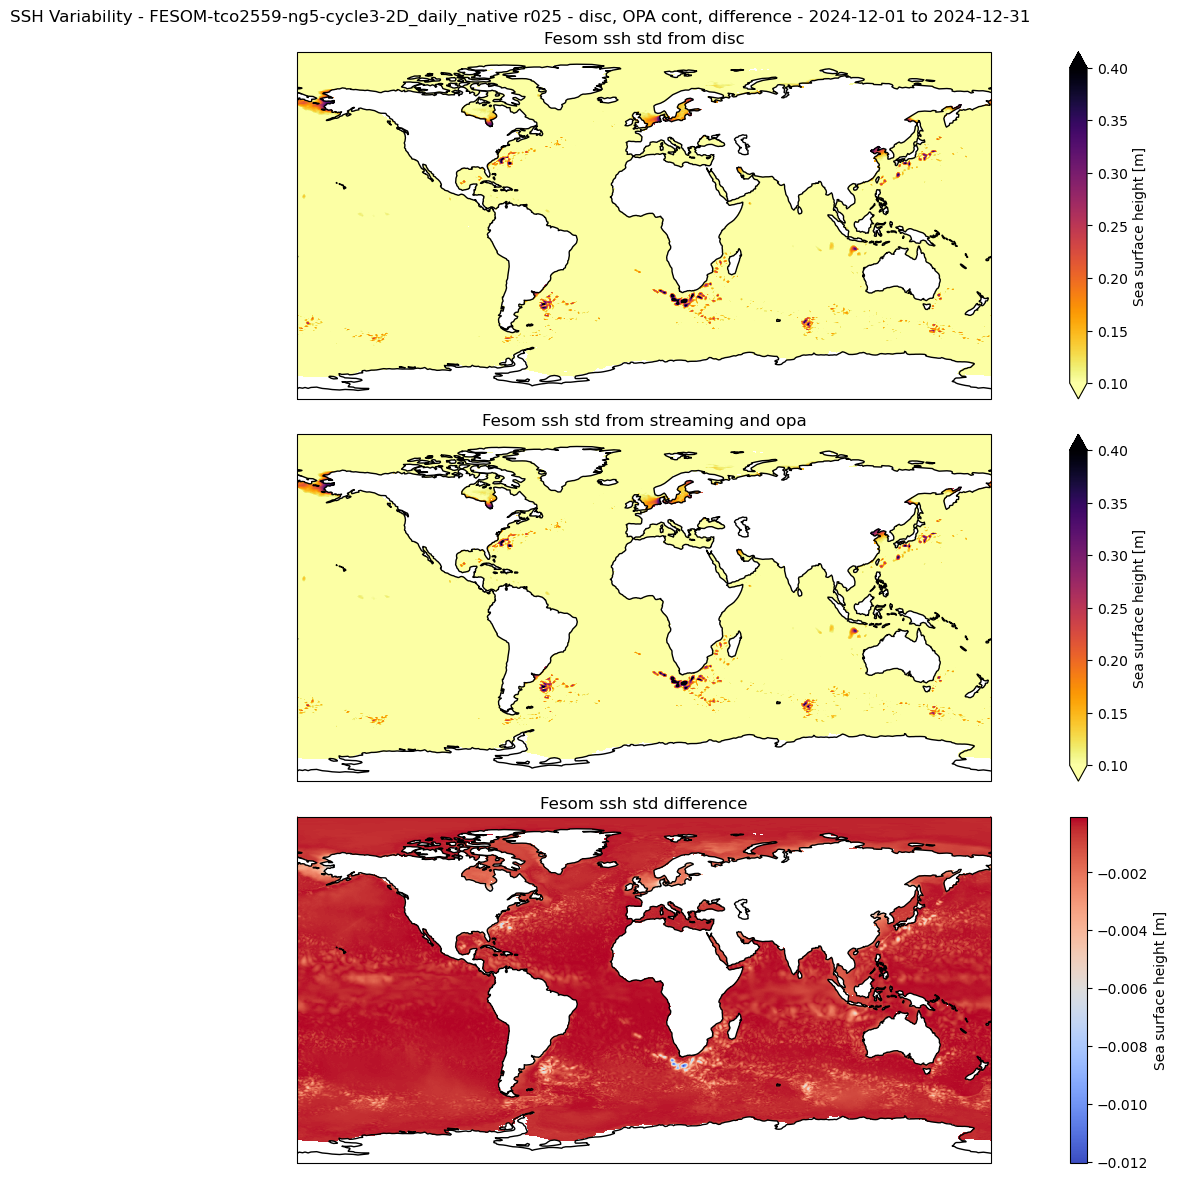

In [9]:
# Broadcast 'fesom_opa' along the 'time' dimension to match the shape of 'fesom_disc'
fesom_disc_broadcasted = fesom_disc.broadcast_like(fesom_opa)

# Perform the difference
difference = fesom_disc_broadcasted['zos'] - fesom_opa['zos']
regridded_diff = reader.regrid(difference)
regridded_fesom_disc = reader.regrid(fesom_disc)
regridded_fesom_opa = reader.regrid(fesom_opa)

fig, axes = plt.subplots(nrows=3, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle("SSH Variability - FESOM-tco2559-ng5-cycle3-2D_daily_native r025 - disc, OPA cont, difference - 2024-12-01 to 2024-12-31")

# Plot the first dataset on the first subplot
regridded_fesom_disc['zos'].plot(ax=axes[0], transform=ccrs.PlateCarree(), vmin=0.1, vmax=0.4, cmap=plt.cm.inferno.reversed())
axes[0].set_title("Fesom ssh std from disc")
axes[0].coastlines()

# Plot the second dataset on the second subplot
regridded_fesom_opa['zos'].plot(ax=axes[1], transform=ccrs.PlateCarree(), vmin=0.1, vmax=0.4, cmap=plt.cm.inferno.reversed())
axes[1].set_title("Fesom ssh std from streaming and opa")
axes[1].coastlines()

# Plot the third dataset on the third subplot
regridded_diff.plot(ax=axes[2], transform=ccrs.PlateCarree(), cmap='coolwarm')
axes[2].set_title("Fesom ssh std difference")
axes[2].coastlines()

fig.tight_layout()
plt.show()

save_subplots_as_jpeg(os.getcwd(), "ssh_disc_opa_diff_1month.jpeg", fig)

### Two pass computation uses float32
The computation precision of the standard deviation depends on the data type of the input array. If the input array is of type float32, the computation will be performed using float32, and if it is of type float64, the computation will be performed using float64.

In [7]:
fesom_cat_std

<xarray.DataArray 'zos' (nod2: 7402886)>
dask.array<_sqrt, shape=(7402886,), dtype=float32, chunksize=(7402886,), chunktype=numpy.ndarray>
Dimensions without coordinates: nod2
Attributes:
    description:  sea surface elevation
    long_name:    Sea surface height
    units:        m
    history:      2023-07-21 10:44:24 variable derived by AQUA fixer;\n
    paramId:      262124
    cfVarName:    zos
    shortName:    zos
    derived:      ssh